## Classifying handwritten digits

consider reading following materials for further details:

Chapter 6, Deep Feedforward Networks, Deep Learning, by I. Goodfellow, Y. Bengio, and A. Courville, MIT Press, 2016 (manuscripts freely accessible at http://www.deeplearningbook.org).
Pattern Recognition and Machine Learning, by C. M. Bishop, Springer New York, 2006.
Lecture video slides from Sebastian Raschka’s deep learning course:
        https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression
          https://sebastianraschka.com/blog/2021/dl-course.html#l09-multilayer-perceptrons-and-backpropration

# Obtaining and preparing the MNIST dataset

In [23]:
from sklearn.datasets import fetch_openml
X,y = fetch_openml('mnist_784', version= 1, return_X_y= True)

X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [24]:
# normalizing  to the range between -1 and 1 for gradient boosting and data preprocessing optimization

X = ((X/255)-0.5)*2


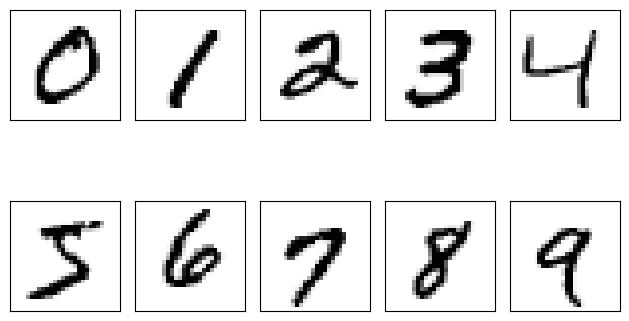

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows= 2, ncols= 5, sharex= True, sharey= True)

ax = ax.flatten()

for i in range(10):
    img = X[y == i][0].reshape(28,28)
    ax[i].imshow(img, cmap = 'Greys')


ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()

In [26]:
from sklearn.model_selection import train_test_split
x_temp,x_test,y_temp,y_test = train_test_split(X,y, test_size= 10000, random_state=123, stratify= y)

x_train,x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size= 5000, random_state = 122)



# MOST INTERESTING PART: NEURAL NETS
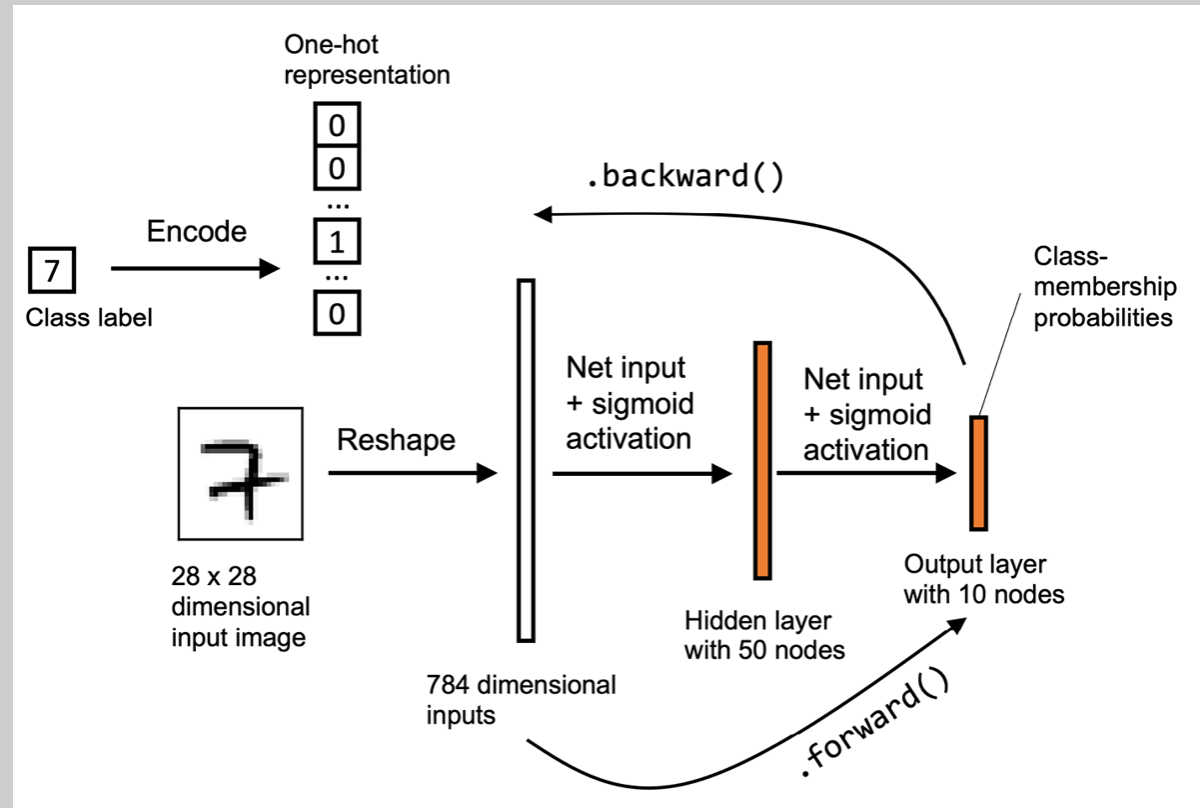
THE ARCHITECTURE

# NEURAL NET ARCHITECTURE

In [27]:
import numpy as np


##########################
### MODEL
##########################

def sigmoid(z):
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()

        self.num_classes = num_classes

        # hidden
        rng = np.random.RandomState(random_seed)

        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)

        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):  
    
        #########################
        ### Output layer weights
        #########################
        
        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use
        
        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights
        
        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h
        
        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        

        #################################        
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight
        
        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out
        
        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)
        
        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative
        
        # [n_examples, n_features]
        d_z_h__d_w_h = x
        
        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return d_loss__dw_out, d_loss__db_out, d_loss__d_w_h, d_loss__d_b_h

In [28]:
# INSTANTIATING THE NEUALNETMLP CLASS
 
model = NeuralNetMLP(num_features=28*28, num_hidden= 50, num_classes=10)



# coding the neural network  training loop

In [29]:
num_ebochs = 50
minbatch = 100

def minbatch_generator(X,y,minbatch):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, indices.shape[0] - minbatch + 1, minbatch):
        batch_idx =  indices[start_idx:start_idx + minbatch]
        yield X[batch_idx], y[batch_idx]
# lets confirm if it is working

for i in range(num_ebochs):
    minbatch_gen = minbatch_generator(x_train, y_train, minbatch)
    for x_train_mini, y_train_mini in minbatch_gen:
        break
    break
print(x_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


# defining loss function  perfomance metrics


In [30]:
def mse_lost(targets, probas, num_labels =  10):
    one_hot_encoder_targets =  int_to_onehot(targets, num_labels= num_labels)
    return np.mean((one_hot_encoder_targets - probas)** 2)

def accuracy(accurates,predicted_values):
    return np.mean(predicted_values == accurates)


In [31]:
_, probas = model.forward(x_val)
mse = mse_lost(y_val, probas)
print(f"initial validation mse : {mse:.1f}")

predicted_val = np.argmax(probas, axis = 1)
acc= accuracy(y_val, predicted_val)

print(f"fthe accuracy is {acc * 100:.1f}%")

initial validation mse : 0.3
fthe accuracy is 9.0%


In [35]:
def compute_mse_accura(nnet, X, y , num_labels = 10, minibatch_size = 100):

    mse, correct_pred, num_examples = 0. , 0, 0
    minbatch = minbatch_generator(X, y, minibatch_size)
    for i , (features, targets ) in enumerate(minbatch):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        onehot_targets = int_to_onehot(targets, num_labels= num_labels)
        loss = np.mean((onehot_targets - probas) ** 2)
        correct_pred += (predicted_labels == targets).sum()
        num_examples += targets.shape[0]
        mse += loss

    mse = mse/i
    acc = correct_pred/num_examples
    return mse, acc
    

In [36]:
mse,acc = compute_mse_accura(model, x_val, y_val)
print(f"iniitial mse is {mse:.1f}")

print(f"initial accuracy {acc *100:.1f}%")

iniitial mse is 0.3
initial accuracy 9.0%


In [37]:
def train(model, X_train, y_train, X_valid, y_valid, num_epoch, learning_rate = 0.01):
    epoch_loss = []
    epoch_train_acc = []
    epoch_val_acc = []
    for e in range(num_epoch):
        minbatch_gen = minbatch_generator(X_train,y_train, minbatch)

        for X_train_mini, y_train_mini in minbatch_gen:
            a_h, a_out = model.forward(X_train_mini)
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = model.backward(X_train_mini, a_h, a_out, y_train_mini)

            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out

        train_mse, train_acc = compute_mse_accura(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_accura(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_val_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epoch:03d} 'f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_val_acc


In [38]:
np.random.seed(123)
epoch_loss, epoch_train_acc, epoch_val_acc = train(model, x_train,y_train, x_val, y_val, num_epoch= 50, learning_rate= 0.1)

Epoch: 001/050 | Train MSE: 0.05 | Train Acc: 76.89% | Valid Acc: 76.32%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 85.48% | Valid Acc: 84.56%
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 87.91% | Valid Acc: 87.16%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 89.34% | Valid Acc: 88.30%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.25% | Valid Acc: 89.34%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.73% | Valid Acc: 90.10%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 91.14% | Valid Acc: 90.56%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 91.46% | Valid Acc: 90.78%
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 91.74% | Valid Acc: 91.30%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.03% | Valid Acc: 91.44%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.22% | Valid Acc: 91.80%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.46% | Valid Acc: 91.86%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.67% | Valid Acc: 92.08%
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 92.79

# evaluaating the neural network perfomance

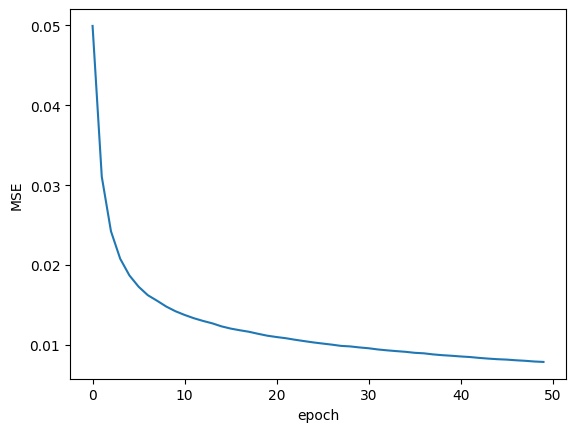

In [40]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.show()

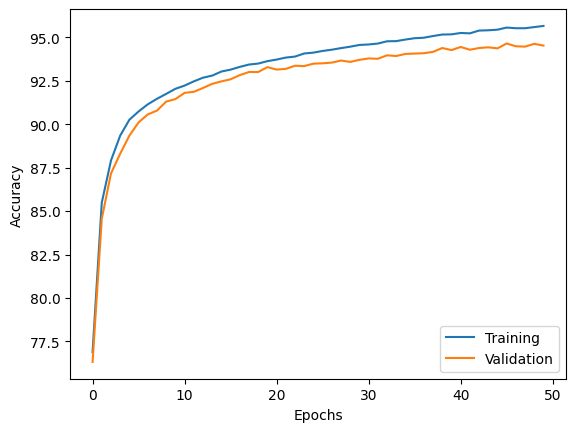

In [41]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,label='Training')
plt.plot(range(len(epoch_val_acc)), epoch_val_acc,label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.show()

In [43]:
test_mse, test_acc= compute_mse_accura(model, x_test, y_test)
print(f"the accuracy is {test_acc *100:.2f}%")

the accuracy is 94.57%
